In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_absolute_error as mae
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings 
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("ola.csv")

In [7]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        9254 non-null   float64
 4   humidity    9254 non-null   float64
 5   windspeed   9254 non-null   float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 765.6+ KB


In [9]:
df.describe()

,season,weather,temp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,9254.000000,9254.000000,9254.000000,10886.000000,10886.000000,10886.000000
mean,2.493937,2.491916,23.240116,124.452421,34.549616,24.517545,99.551442,224.177267
std,1.120531,1.123139,20.311144,75.568291,28.417263,14.390014,57.541131,75.228602
min,1.000000,1.000000,-22.743852,32.713561,-1.407737,0.000000,0.000000,-12.769738
25%,1.000000,1.000000,12.470555,87.846187,17.963252,12.000000,50.000000,170.140221
50%,2.000000,2.000000,20.743790,112.180064,30.945593,25.000000,100.000000,224.257587
75%,3.000000,4.000000,29.394576,137.301002,44.029018,37.000000,149.000000,278.407366
max,4.000000,4.000000,211.102548,672.687236,244.921965,49.000000,199.000000,464.839068


In [10]:
df.shape

(10886, 9)

In [11]:
df["datetime"]=pd.to_datetime(df["datetime"])
df["month"]=df["datetime"].dt.month
df["year"]=df["datetime"].dt.year
df["day"]=df["datetime"].dt.day
df['hour']=df['datetime'].dt.hour
df['time']=df['datetime'].dt.time

df["day of week"]=df["datetime"].dt.weekday.apply(lambda x:1 if x<5 else 0)
df["am or pm"]=df['hour'].apply(lambda x:1 if x<11 else 0)
df["week of year"]=df["datetime"].dt.isocalendar().week



In [12]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,month,year,day,hour,time,day of week,am or pm,week of year
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,1,2011,1,0,00:00:00,0,1,52
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,2011,1,1,01:00:00,0,1,52
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,1,2011,1,2,02:00:00,0,1,52
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,1,2011,1,3,03:00:00,0,1,52
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,1,2011,1,4,04:00:00,0,1,52


In [13]:
df.drop("datetime", axis=1,inplace=True)

In [14]:
df.isnull().sum()

season             0
weather            0
temp            1632
humidity        1632
windspeed       1632
casual             0
registered         0
count              0
month              0
year               0
day                0
hour               0
time               0
day of week        0
am or pm           0
week of year       0
dtype: int64

In [15]:
numeric_features = df.select_dtypes(include=np.number).columns


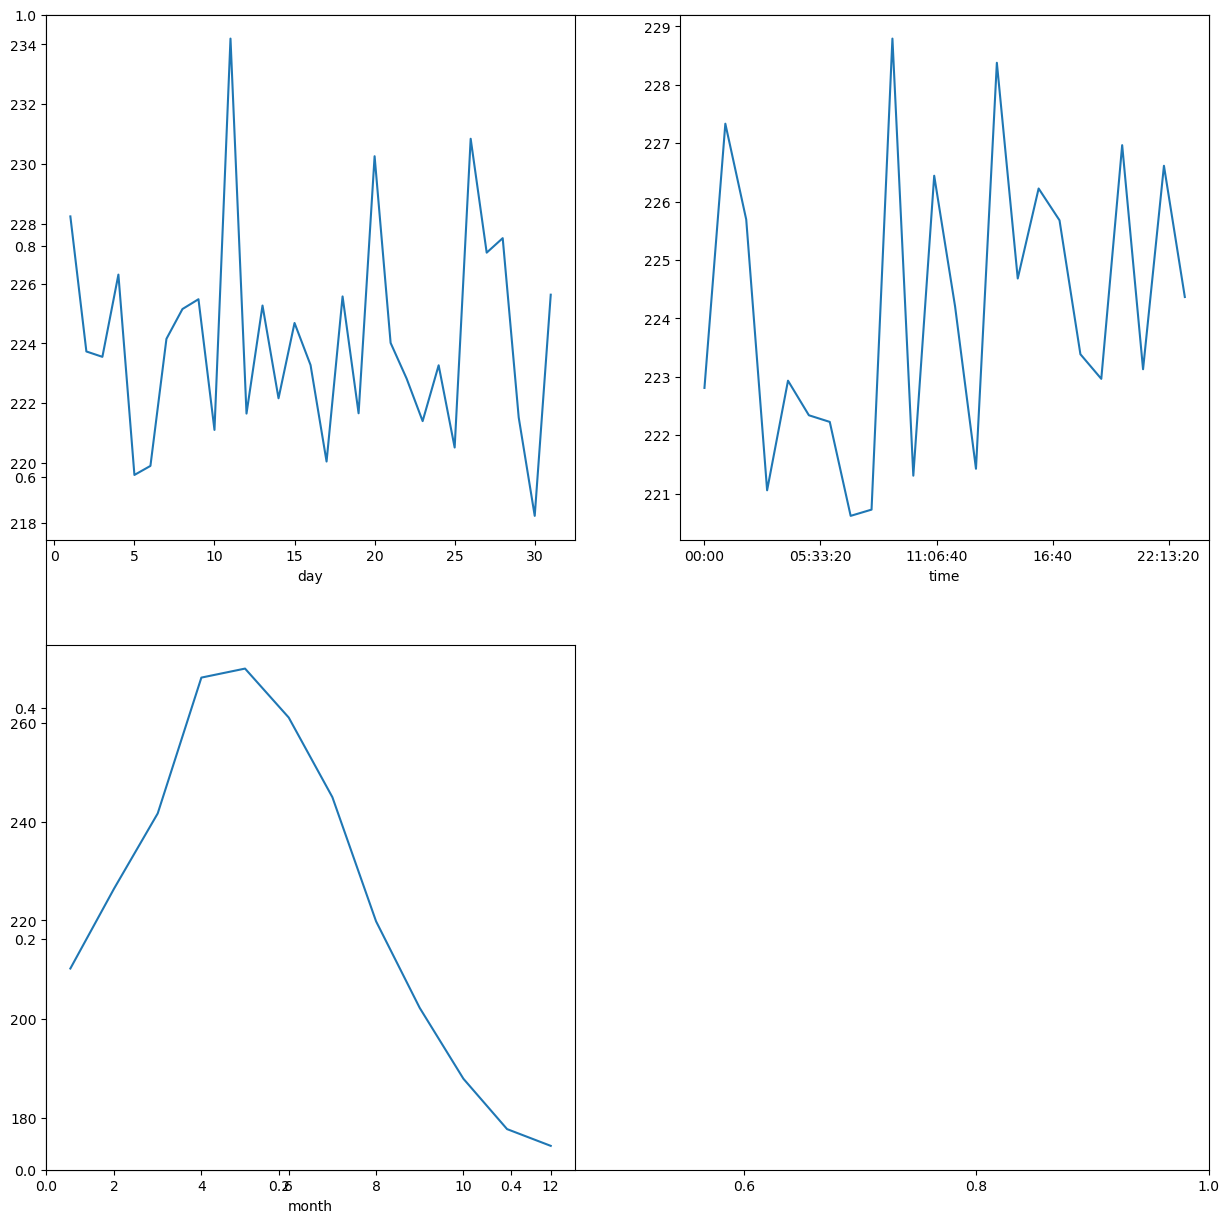

In [16]:
numeric_features = ['day', 'time', 'month']

plt.subplots(figsize=(15, 15))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['count'].mean().plot()
plt.show()

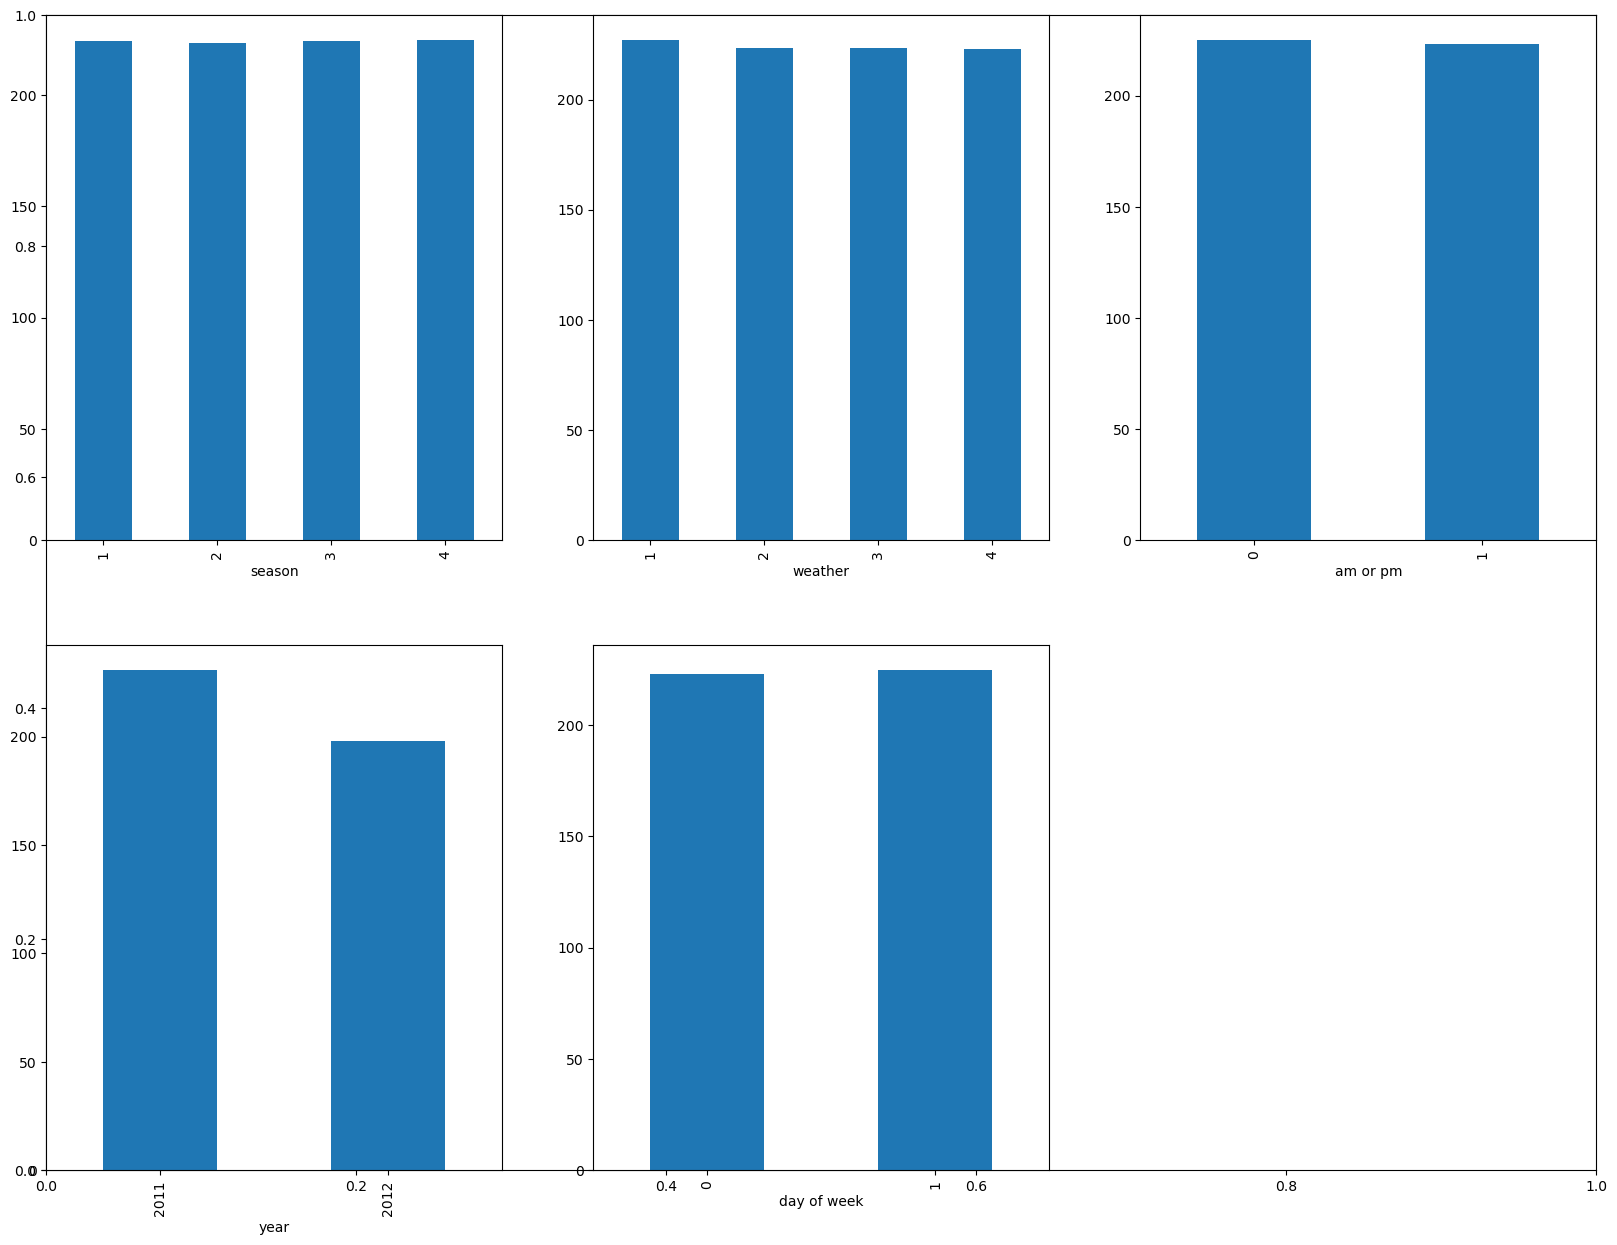

In [17]:
numeric_features = ['season', 'weather',\
            'am or pm', 'year', 'day of week']

plt.subplots(figsize=(20, 15))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col)['count'].mean().plot.bar()
plt.show()

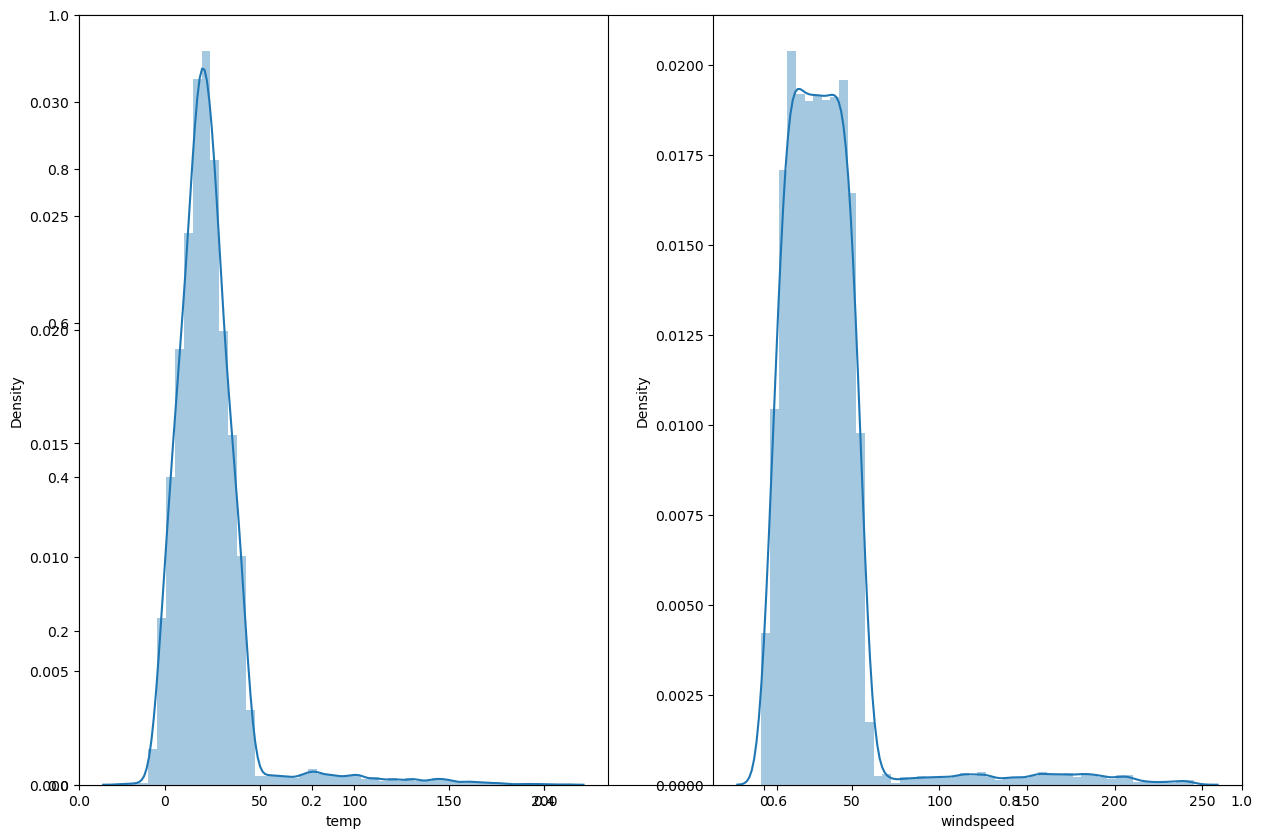

In [18]:
numeric_features=["temp","windspeed"]
plt.subplots(figsize=(15,10))
for i,col in enumerate(numeric_features):
    plt.subplot(1,2,i+1)
    sns.distplot(df[col])
plt.show()


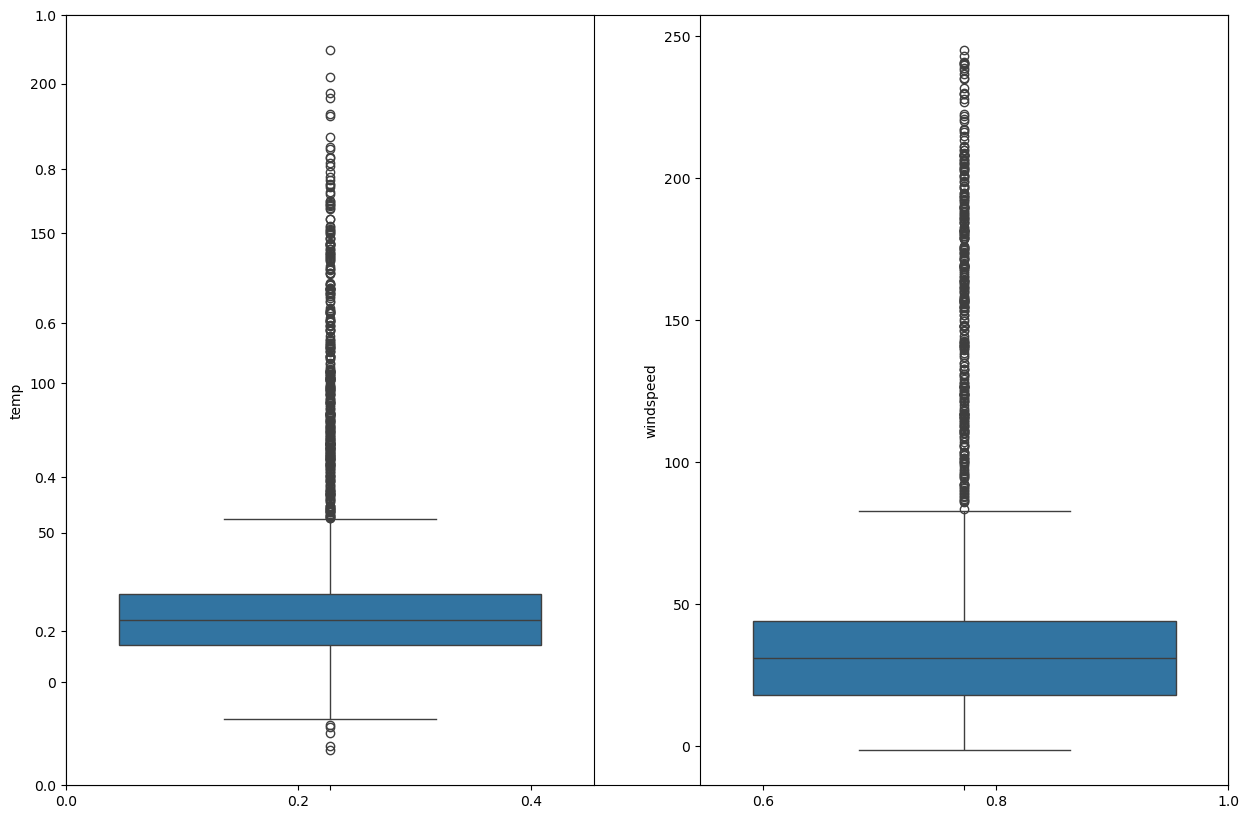

In [19]:
numeric_features=["temp","windspeed"]
plt.subplots(figsize=(15,10))
for i,col in enumerate(numeric_features):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col])
plt.show()

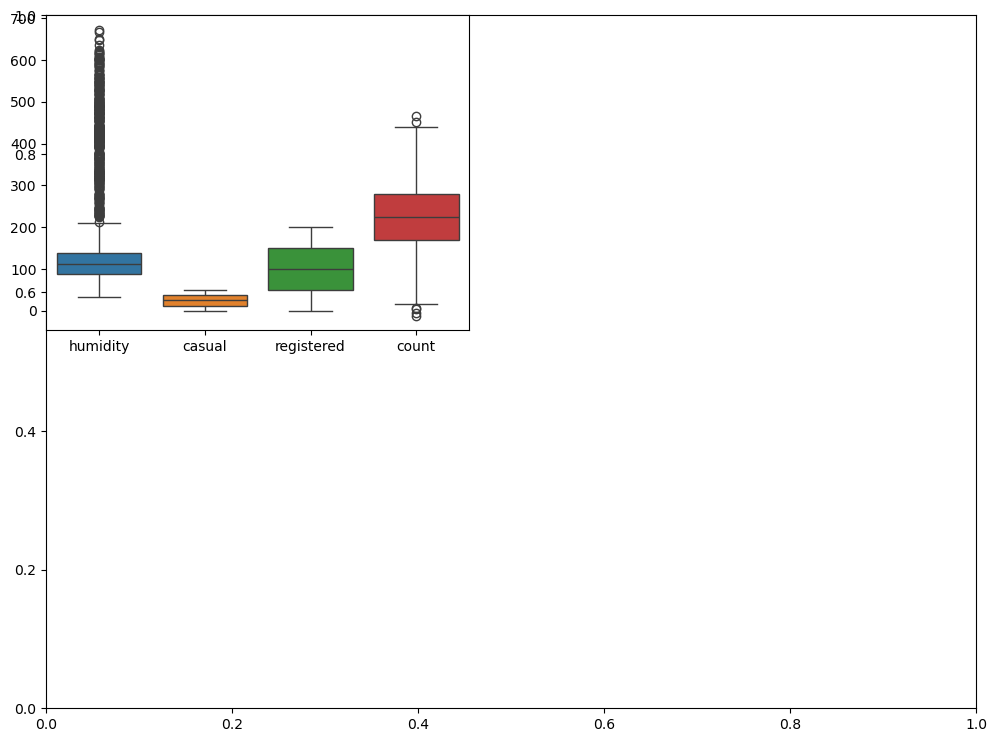

In [20]:
numeric_features=[['humidity', 'casual', 'registered', 'count']]
plt.subplots(figsize=(12,9))
for i,col in enumerate(numeric_features):
    plt.subplot(2,2,i+1)
    sns.boxplot(df[col])
plt.show()

In [21]:
numeric_df = df.select_dtypes(include='number')

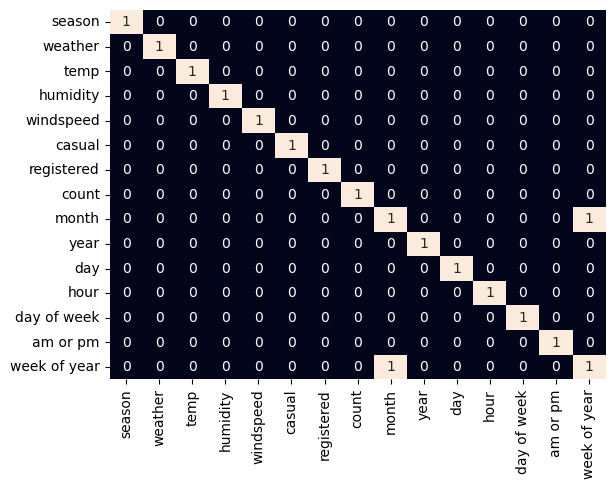

In [22]:
sns.heatmap(numeric_df.corr()>0.8,annot=True,cbar=False)
plt.show()

In [23]:
df.head()

,season,weather,temp,humidity,windspeed,casual,registered,count,month,year,day,hour,time,day of week,am or pm,week of year
0,3,2,7.653428,122.430885,18.783703,5,128,315.731778,1,2011,1,0,00:00:00,0,1,52
1,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,2011,1,1,01:00:00,0,1,52
2,1,3,30.886922,77.583743,45.365080,34,97,224.278595,1,2011,1,2,02:00:00,0,1,52
3,3,1,10.463377,114.925671,25.347168,6,47,132.169549,1,2011,1,3,03:00:00,0,1,52
4,3,4,30.214783,149.193592,20.288982,14,199,315.867137,1,2011,1,4,04:00:00,0,1,52


In [24]:
df.drop(['registered', 'time'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

In [25]:
X = df.drop(['count'], axis=1)  # keep only numeric
y = df['count']  # your target

In [26]:
features = df.drop(['count'], axis=1)
target = df['count'].values

X_train, X_test, y_train, y_test = train_test_split(features,
                                                  target,
                                                  test_size = 0.1,
                                                  random_state=22)
X_train.shape, X_test.shape

((4315, 13), (480, 13))

In [27]:
X_train_numeric = X_train.select_dtypes(include='number')
X_test_numeric = X_test.select_dtypes(include='number')

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [30]:

# List of models
models = [LinearRegression(), Lasso(), RandomForestRegressor(), Ridge()]

# Fit and evaluate each model
for model in models:
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    train_preds = model.predict(X_train_scaled)
    val_preds = model.predict(X_test_scaled)
    
    # Print results
    print(f'{model.__class__.__name__}:')
    print('Training MAE:', mae(y_train, train_preds))
    print('Validation MAE:', mae(y_test, val_preds))
    print('-----------------------------')


LinearRegression:
Training MAE: 55.388005222702155
Validation MAE: 55.64230010702775
-----------------------------
Lasso:
Training MAE: 55.414574745653766
Validation MAE: 55.67277618910759
-----------------------------
RandomForestRegressor:
Training MAE: 20.57639514208229
Validation MAE: 56.25290404847892
-----------------------------
Ridge:
Training MAE: 55.38790549344838
Validation MAE: 55.64269706137237
-----------------------------


In [31]:
RFG=RandomForestRegressor()
RFG.fit(X_train,y_train)

RandomForestRegressor()

In [32]:
y_pred=RFG.predict(X_test)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [35]:
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 4497.935347572879
MAE: 55.481238255479475
R2 Score: 0.20677538525479555
